In [1]:
# Exploratory Data Analysis (EDA)
## State-Level Rice & Wheat Allocation under PDS

# Scope and assumptions:
# - Analysis is restricted to **state-level aggregation**
# - Allocation quantities are treated as a proxy for consumption
# - Missing allocation values for ePoS / non-ePoS are treated as **0**, 
#   representing non-usage of that channel
# - EDA period starts from **October 2017** to avoid partial-year bias
# - COVID period (from March 2020) is considered while interpreting trends

# All aggregation and plotting logic is implemented in reusable utilities (`src/eda_utils.py`)
# to ensure consistency across notebooks and Streamlit.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import sys

In [3]:
# Project root
PROJECT_ROOT = Path.cwd().parents[0]
sys.path.append(str(PROJECT_ROOT))

In [4]:
from src.eda_utils import (
    get_national_monthly_allocation,
    plot_national_allocation,
    get_zoomed_period,
    plot_allocation_anomaly
)

In [5]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)


In [6]:
DATA_PATH = "../data/cleaned/"

In [7]:
# LOADING DATA
df_eda = pd.read_csv(DATA_PATH+"primary_data_clean.csv", parse_dates=["date"])
# Focus on reliable window
df_eda = df_eda[df_eda["date"] >= "2017-10-01"]

df_eda.head()

,country_code,state_name,state_code,dfso,district_code,full_district_code,current_year,financial_year,month,month_num,quarter,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty
0,IN,tamil nadu,TN,Pudukkottai,PU,IN.TN.PU,2021,2021,october,10,2021Q4,2021-10-01,rice,6445.00,5595.02,NaN
1,IN,tamil nadu,TN,Pudukkottai,PU,IN.TN.PU,2021,2021,october,10,2021Q4,2021-10-01,wheat,599.00,395.49,NaN
2,IN,andhra pradesh,AP,Anantapur,AN,IN.AP.AN,2021,2021,september,9,2021Q3,2021-09-01,rice,13030.41,12247.06,NaN
3,IN,andhra pradesh,AP,Chittoor,CH,IN.AP.CH,2021,2021,september,9,2021Q3,2021-09-01,rice,14176.89,13199.87,NaN
4,IN,andhra pradesh,AP,East Godavari,EG,IN.AP.EG,2021,2021,september,9,2021Q3,2021-09-01,rice,16541.31,15778.81,NaN


In [8]:
df_eda.shape

(66735, 16)

In [9]:
df_eda.head()

,country_code,state_name,state_code,dfso,district_code,full_district_code,current_year,financial_year,month,month_num,quarter,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty
0,IN,tamil nadu,TN,Pudukkottai,PU,IN.TN.PU,2021,2021,october,10,2021Q4,2021-10-01,rice,6445.00,5595.02,NaN
1,IN,tamil nadu,TN,Pudukkottai,PU,IN.TN.PU,2021,2021,october,10,2021Q4,2021-10-01,wheat,599.00,395.49,NaN
2,IN,andhra pradesh,AP,Anantapur,AN,IN.AP.AN,2021,2021,september,9,2021Q3,2021-09-01,rice,13030.41,12247.06,NaN
3,IN,andhra pradesh,AP,Chittoor,CH,IN.AP.CH,2021,2021,september,9,2021Q3,2021-09-01,rice,14176.89,13199.87,NaN
4,IN,andhra pradesh,AP,East Godavari,EG,IN.AP.EG,2021,2021,september,9,2021Q3,2021-09-01,rice,16541.31,15778.81,NaN


In [10]:
df_eda.sample(5)

,country_code,state_name,state_code,dfso,district_code,full_district_code,current_year,financial_year,month,month_num,quarter,date,commodity,total_allocated_qty,epos_allocated_qty,not_epos_allocated_qty
51916,IN,rajasthan,RJ,PALI,PA,IN.RJ.PA,2018,2018,september,9,2018Q3,2018-09-01,wheat,6394.30,5552.28,NaN
60389,IN,uttar pradesh,UP,HAMIRPUR,HM,IN.UP.HM,2018,2018,april,4,2018Q2,2018-04-01,wheat,2975.08,428.01,NaN
30637,IN,bihar,BR,"DISTRICT SUPPLY OFFICE , NALANDA",NaN,NaN,2019,2019,october,10,2019Q4,2019-10-01,wheat,208.13,NaN,1743.27
62509,IN,kerala,KL,DSO KOZHIKKODE,NaN,NaN,2018,2017,february,2,2018Q1,2018-02-01,wheat,1492.16,NaN,1424.36
42765,IN,uttar pradesh,UP,LALITPUR,LA,IN.UP.LA,2019,2018,march,3,2019Q1,2019-03-01,rice,2071.50,2009.98,NaN


In [11]:
df_eda.isna().sum()

country_code                  0
state_name                    0
state_code                    0
dfso                          0
district_code             23216
full_district_code        23000
current_year                  0
financial_year                0
month                         0
month_num                     0
quarter                       0
date                          0
commodity                     0
total_allocated_qty         396
epos_allocated_qty        22225
not_epos_allocated_qty    44023
dtype: int64

In [12]:
df_eda.info()

<class 'pandas.core.frame.DataFrame'>
Index: 66735 entries, 0 to 66734
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   country_code            66735 non-null  object        
 1   state_name              66735 non-null  object        
 2   state_code              66735 non-null  object        
 3   dfso                    66735 non-null  object        
 4   district_code           43519 non-null  object        
 5   full_district_code      43735 non-null  object        
 6   current_year            66735 non-null  int64         
 7   financial_year          66735 non-null  int64         
 8   month                   66735 non-null  object        
 9   month_num               66735 non-null  int64         
 10  quarter                 66735 non-null  object        
 11  date                    66735 non-null  datetime64[ns]
 12  commodity               66735 non-null  object     

In [13]:
df_eda.describe().T

,count,mean,min,25%,50%,75%,max,std
current_year,66735.0,2019.232816,2017.0,2018.0,2019.0,2020.0,2021.0,1.122984
financial_year,66735.0,2018.97063,2017.0,2018.0,2019.0,2020.0,2021.0,1.145147
month_num,66735.0,6.316236,1.0,3.0,6.0,9.0,12.0,3.433103
date,66735,2019-09-04 05:30:05.906945536,2017-10-01 00:00:00,2018-10-01 00:00:00,2019-09-01 00:00:00,2020-08-01 00:00:00,2021-10-01 00:00:00,NaN
total_allocated_qty,66339.0,4045.507977,0.01,900.47,2946.63,5604.67,839904.3,10538.64234
epos_allocated_qty,44510.0,3160.334211,0.01,775.595,2399.345,4690.97,49492.99,3020.592562
not_epos_allocated_qty,22712.0,1888.608581,0.01,71.87,419.465,2098.865,655202.0,9669.931326


In [14]:
# FILLING NULL VALUES WITH 0
alloc_cols = [
    "total_allocated_qty",
    "epos_allocated_qty",
    "not_epos_allocated_qty"
]

df_eda[alloc_cols] = df_eda[alloc_cols].fillna(0)

assert (df_eda[alloc_cols] >= 0).all().all()


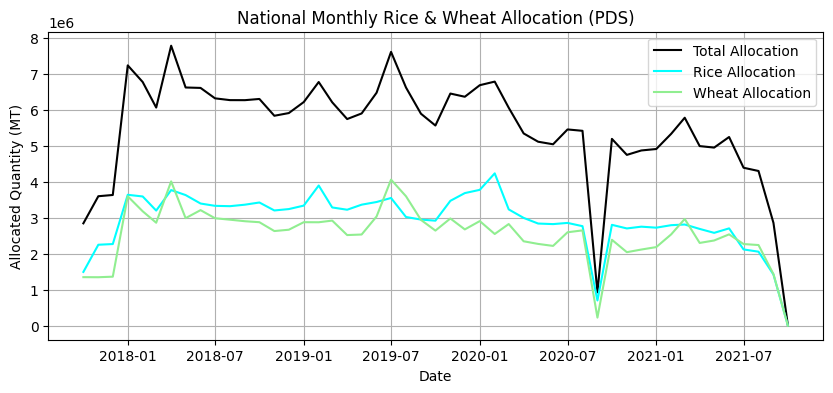

In [15]:
##  National Foodgrain Allocation Over Time

national_df = get_national_monthly_allocation(df_eda)
national_df.head()
fig = plot_national_allocation(national_df)
plt.show()


In [16]:
### Key Observations
# - Rice consistently accounts for a larger share of allocations than wheat
# - No long-term declining trend is evident at the national level


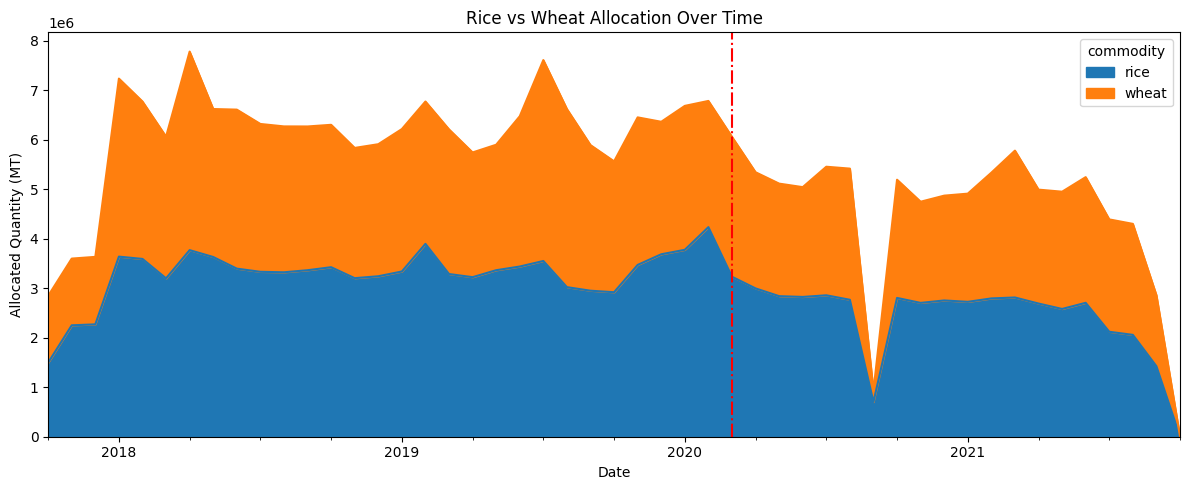

In [17]:
## Commodity-wise Allocation Over Time

commodity_ts = (
    df_eda
    .groupby(["date", "commodity"], as_index=False)
    .agg(total_allocated_qty=("total_allocated_qty", "sum"))
)

pivot_commodity = commodity_ts.pivot(
    index="date", columns="commodity", values="total_allocated_qty"
)

pivot_commodity.plot(
    kind="area",
    figsize=(12, 5),
    stacked=True
)

plt.axvline(pd.Timestamp("2020-03-25"), linestyle="-.", color="red")
plt.title("Rice vs Wheat Allocation Over Time")
plt.xlabel("Date")
plt.ylabel("Allocated Quantity (MT)")
plt.tight_layout()
plt.show()


In [18]:
# ------------------------------------
# NEED TO ANALYSE THE SHARP DECREASE
# ------------------------------------

In [19]:
# Focus window
period_df = get_zoomed_period(
    national_df,
    start_date="2020-07-01",
    end_date="2021-01-31"
)

period_df

commodity,date,rice_allocated,wheat_allocated,total_allocated_qty,mom_change,mom_pct_change
33,2020-07-01,2858405.62,2598342.36,5456747.98,NaN,NaN
34,2020-08-01,2767844.10,2650666.70,5418510.80,-38237.18,-0.700732
35,2020-09-01,702456.07,225897.01,928353.08,-4490157.72,-82.867007
36,2020-10-01,2804996.11,2389252.90,5194249.01,4265895.93,459.512229
37,2020-11-01,2704925.58,2044545.58,4749471.16,-444777.85,-8.562890
38,2020-12-01,2754039.15,2118338.04,4872377.19,122906.03,2.587783
39,2021-01-01,2726323.83,2186400.45,4912724.28,40347.09,0.828078


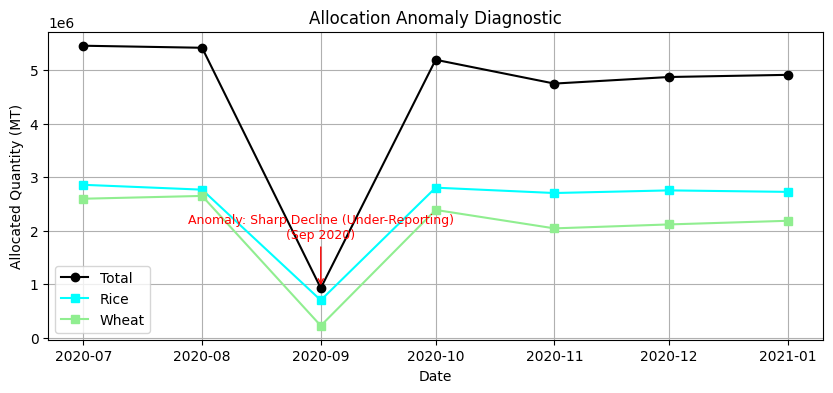

In [20]:
fig = plot_allocation_anomaly(period_df)
plt.show()

In [21]:
### Anomaly Detection

# A sharp decline is observed in **September 2020**, followed by a strong rebound.
# This pattern is inconsistent with true consumption shocks and likely reflects temporary under-reporting 
# by one or more large states rather than a structural demand collapse.


In [22]:
period_df.sort_values("mom_change")

commodity,date,rice_allocated,wheat_allocated,total_allocated_qty,mom_change,mom_pct_change
35,2020-09-01,702456.07,225897.01,928353.08,-4490157.72,-82.867007
37,2020-11-01,2704925.58,2044545.58,4749471.16,-444777.85,-8.562890
34,2020-08-01,2767844.10,2650666.70,5418510.80,-38237.18,-0.700732
39,2021-01-01,2726323.83,2186400.45,4912724.28,40347.09,0.828078
38,2020-12-01,2754039.15,2118338.04,4872377.19,122906.03,2.587783
36,2020-10-01,2804996.11,2389252.90,5194249.01,4265895.93,459.512229
33,2020-07-01,2858405.62,2598342.36,5456747.98,NaN,NaN


In [23]:
collapse_row = period_df.loc[period_df["mom_change"].idxmin()]

collapse_date = collapse_row["date"]
collapse_value = collapse_row["total_allocated_qty"]
collapse_change = collapse_row["mom_change"]

collapse_date, collapse_change


(Timestamp('2020-09-01 00:00:00'), np.float64(-4490157.720000001))

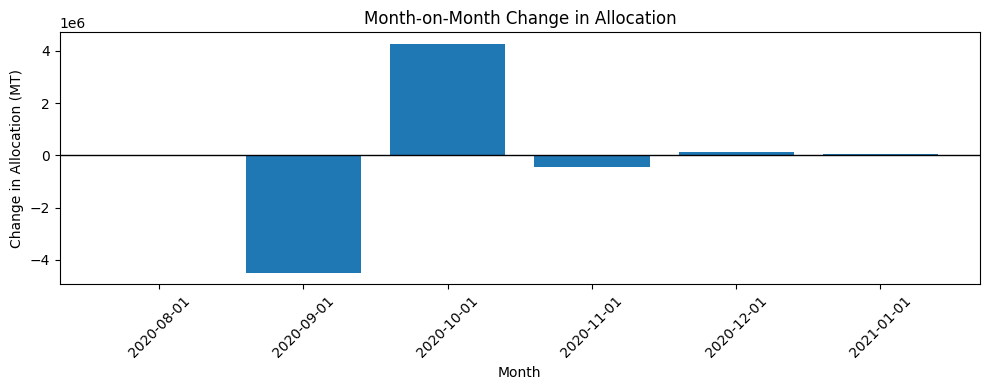

In [24]:
plt.figure(figsize=(10, 4))
plt.bar(
    period_df["date"].astype(str),
    period_df["mom_change"]
)

plt.axhline(0, color="black", linewidth=1)
plt.title("Month-on-Month Change in Allocation")
plt.xlabel("Month")
plt.ylabel("Change in Allocation (MT)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [25]:
# Anomalous drop observed between Jul 2020 and Jan 2021.
# Preliminary analysis suggests likely under-reporting by one or more large states rather than a true demand shock.
# Large amount of September 2020 is under-reported/missing
# This period should be treated with caution in downstream modeling.


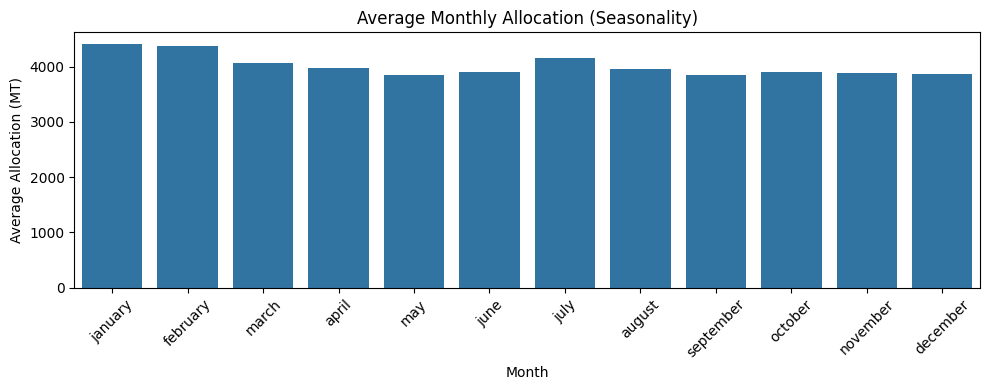

In [26]:
##  Seasonal Pattern in Allocation

month_order = [
    "january","february","march","april","may","june",
    "july","august","september","october","november","december"
]

seasonality = (
    df_eda
    .groupby("month", as_index=False)
    .agg(avg_allocated_qty=("total_allocated_qty", "mean"))
)

seasonality["month"] = pd.Categorical(
    seasonality["month"],
    categories=month_order,
    ordered=True
)
seasonality = seasonality.sort_values("month")

plt.figure(figsize=(10, 4))
sns.barplot(
    data=seasonality,
    x="month",
    y="avg_allocated_qty"
)

plt.title("Average Monthly Allocation (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Allocation (MT)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

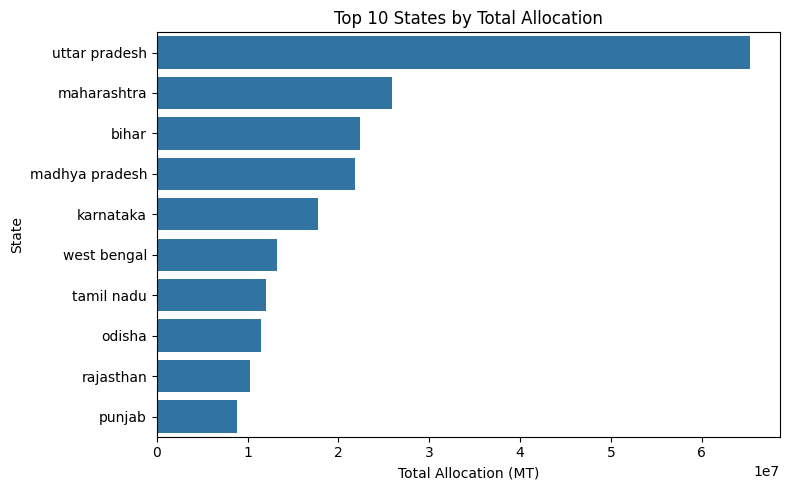

In [27]:
## Top States by Total Allocation

state_totals = (
    df_eda
    .groupby("state_name", as_index=False)
    .agg(total_allocated_qty=("total_allocated_qty", "sum"))
    .sort_values("total_allocated_qty", ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=state_totals,
    y="state_name",
    x="total_allocated_qty"
)

plt.title("Top 10 States by Total Allocation")
plt.xlabel("Total Allocation (MT)")
plt.ylabel("State")
plt.tight_layout()
plt.show()

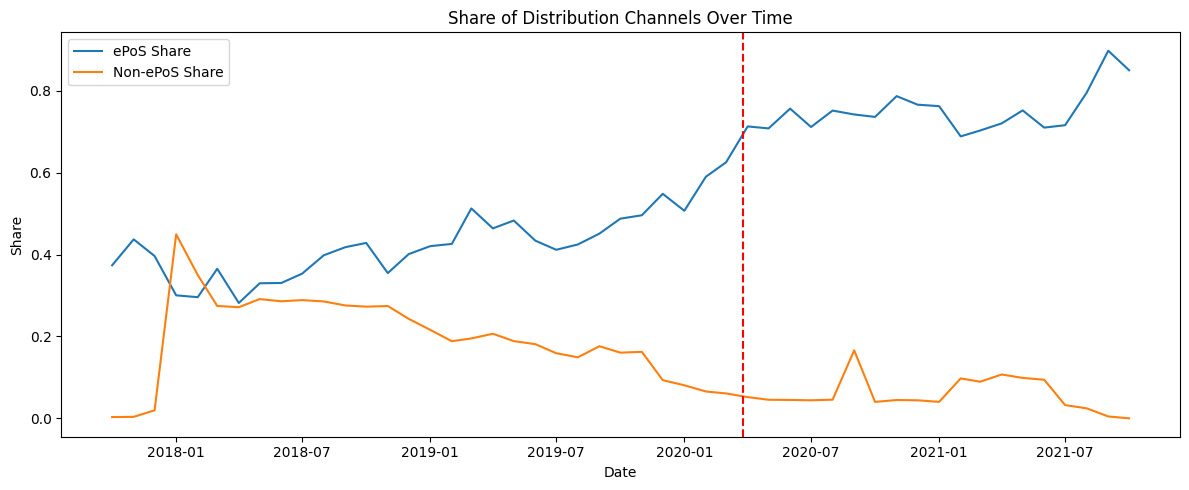

In [28]:
## Distribution Channel Share Over Time

channel_ts = (
    df_eda
    .groupby("date", as_index=False)
    .agg(
        epos=("epos_allocated_qty", "sum"),
        non_epos=("not_epos_allocated_qty", "sum"),
        total=("total_allocated_qty", "sum")
    )
)

channel_ts["epos_share"] = channel_ts["epos"] / channel_ts["total"]
channel_ts["non_epos_share"] = channel_ts["non_epos"] / channel_ts["total"]

plt.figure(figsize=(12, 5))
plt.plot(channel_ts["date"], channel_ts["epos_share"], label="ePoS Share")
plt.plot(channel_ts["date"], channel_ts["non_epos_share"], label="Non-ePoS Share")

plt.axvline(pd.Timestamp("2020-03-25"), linestyle="--", color="red")
plt.title("Share of Distribution Channels Over Time")
plt.xlabel("Date")
plt.ylabel("Share")
plt.legend()
plt.tight_layout()
plt.show()

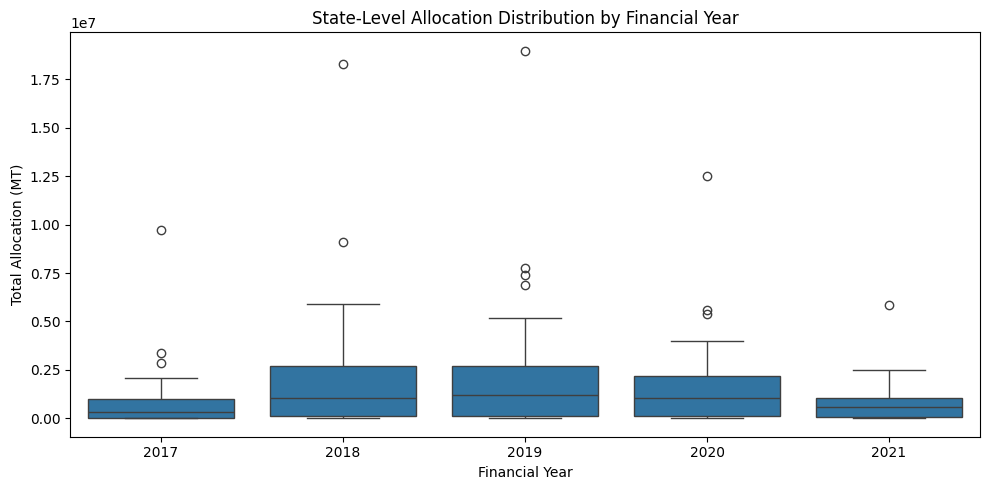

In [29]:
## Distribution of State-Level Allocation by Financial Year

state_yearly = (
    df_eda
    .groupby(["state_name", "financial_year"], as_index=False)
    .agg(total_allocated_qty=("total_allocated_qty", "sum"))
)

plt.figure(figsize=(10, 5))
sns.boxplot(
    data=state_yearly,
    x="financial_year",
    y="total_allocated_qty"
)

plt.title("State-Level Allocation Distribution by Financial Year")
plt.xlabel("Financial Year")
plt.ylabel("Total Allocation (MT)")
plt.tight_layout()
plt.show()